# Crypt: the quantum attack and the post-quantum defense

**Q-Hack India 2026 | Track: Post-Quantum Cryptography**

This notebook runs top to bottom and shows the whole story in four steps:

1. **A toy RSA key** protects a secret message.
2. **Shor's algorithm** (a real quantum circuit, run on the Qiskit Aer simulator) finds the factors of the key's modulus.
3. **The key is broken**: the attacker rebuilds the private key from those factors and reads the message.
4. **Crypt defends**: the same kind of secret is protected with a hybrid X25519 + ML-KEM-768 layer that this attack does not break.

> **Honest scale.** We factor **N = 15** on a simulator. Breaking RSA-2048 needs a far larger, error-corrected quantum computer. The demo shows the *mechanism* of the threat, which is why migration has to start before such machines exist.

## 0. Setup

Run this cell once in Google Colab. **Replace `YOUR-USERNAME` with your GitHub username** before running.

In [1]:
!pip install -q qiskit qiskit-aer matplotlib kyber-py cryptography
!pip install -q git+https://github.com/Pratiush-K/cryptpqc.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import math
from fractions import Fraction
from math import gcd

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

import qiskit, qiskit_aer
print("qiskit", qiskit.__version__, "| qiskit-aer", qiskit_aer.__version__)

qiskit 2.5.2 | qiskit-aer 0.17.2


## 1. A toy RSA key

The owner picks two secret primes `p` and `q`. Everyone sees the public values `N = p*q` and `e`. Security rests on one assumption: nobody can recover `p` and `q` from `N`.

In [3]:
# --- the key owner's secrets ---
p, q = 3, 5
e = 7
phi = (p - 1) * (q - 1)
d = pow(e, -1, phi)          # private exponent

# --- what everyone can see ---
N = p * q
message = 2                  # the secret (must be smaller than N)
ciphertext = pow(message, e, N)

print(f"Public key        : N = {N}, e = {e}")
print(f"Secret message    : {message}")
print(f"Encrypted message : {ciphertext}")
print(f"Owner decrypts    : {pow(ciphertext, d, N)}")

# From here on the attacker only knows N, e and the ciphertext.
del p, q, phi, d

Public key        : N = 15, e = 7
Secret message    : 2
Encrypted message : 8
Owner decrypts    : 2


## 2. Shor's algorithm: finding the period

Pick a number `a` that shares no factor with `N`. The sequence `a^x mod N` repeats with some period `r`. A quantum computer can find `r` efficiently using phase estimation; from `r` the factors follow with two `gcd` calculations.

Here `a = 7` and the circuit uses 8 counting qubits plus 4 qubits that hold the value being multiplied. The controlled multiplications `7^(2^k) mod 15` are precomputed classically (standard practice) and applied as small permutation circuits.

In [4]:
a = 7
n_count = 8                    # counting qubits (precision of the phase estimate)

def c_mult_mod15(k):
    """Controlled 'multiply by k mod 15' acting on 4 target qubits."""
    U = QuantumCircuit(4)
    if k in (2, 13):
        U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
    if k in (7, 8):
        U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
    if k in (4, 11):
        U.swap(1, 3); U.swap(0, 2)
    if k in (7, 11, 13, 14):
        for qubit in range(4):
            U.x(qubit)
    gate = U.to_gate()
    gate.name = f"x{k} mod 15"
    return gate.control()

def inverse_qft(n):
    """Inverse quantum Fourier transform on n qubits."""
    qc = QuantumCircuit(n, name="QFT-inverse")
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    for j in range(n):
        for m in range(j):
            qc.cp(-math.pi / 2 ** (j - m), m, j)
        qc.h(j)
    return qc

qc = QuantumCircuit(n_count + 4, n_count)
qc.h(range(n_count))           # counting qubits into superposition
qc.x(n_count)                  # target register starts as |0001> = 1
for k_bit in range(n_count):
    k = pow(a, 2 ** k_bit, N)  # a^(2^k_bit) mod N, computed classically
    if k != 1:
        qc.append(c_mult_mod15(k), [k_bit] + list(range(n_count, n_count + 4)))
qc.append(inverse_qft(n_count).to_gate(), range(n_count))
qc.measure(range(n_count), range(n_count))

sim = AerSimulator()
compiled = transpile(qc, sim)
print(f"Circuit: {qc.num_qubits} qubits, depth after compiling: {compiled.depth()}")

Circuit: 12 qubits, depth after compiling: 29


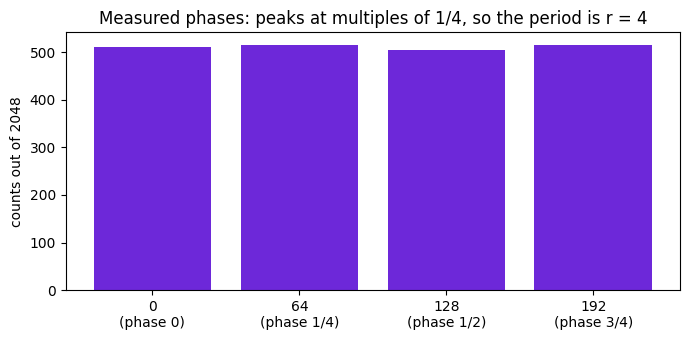

{'11000000': 516, '01000000': 515, '00000000': 512, '10000000': 505}


In [5]:
shots = 2048
counts = sim.run(compiled, shots=shots, seed_simulator=7).result().get_counts()

outcomes = sorted(counts, key=lambda s: int(s, 2))
values = [int(s, 2) for s in outcomes]
heights = [counts[s] for s in outcomes]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(range(len(outcomes)), heights, color="#6d28d9")
ax.set_xticks(range(len(outcomes)))
ax.set_xticklabels([f"{v}\n(phase {Fraction(v, 2**n_count)})" for v in values])
ax.set_ylabel(f"counts out of {shots}")
ax.set_title("Measured phases: peaks at multiples of 1/4, so the period is r = 4")
plt.tight_layout()
plt.show()
print(dict(sorted(counts.items(), key=lambda kv: -kv[1])))

### Reading the result

The counting register collapses to a multiple of `2^8 / r`. With peaks at phases 0, 1/4, 1/2 and 3/4, the denominator tells us the period. We try the measured outcomes, use continued fractions (`limit_denominator`) to get a candidate `r`, and keep one only if `a^r mod N = 1` and `r` is even.

In [6]:
def factors_from_counts(counts, a, N, n_count):
    for bits, _ in sorted(counts.items(), key=lambda kv: -kv[1]):
        phase = int(bits, 2) / 2 ** n_count
        r = Fraction(phase).limit_denominator(N).denominator
        if r % 2 == 0 and pow(a, r, N) == 1:
            f1 = gcd(pow(a, r // 2) - 1, N)
            f2 = gcd(pow(a, r // 2) + 1, N)
            if 1 < f1 < N and 1 < f2 < N:
                return r, sorted((f1, f2))
    return None

result = factors_from_counts(counts, a, N, n_count)
r, (p_found, q_found) = result
print(f"Period found       : r = {r}   (check: {a}^{r} mod {N} = {pow(a, r, N)})")
print(f"Factors of {N}      : {p_found} x {q_found}")

Period found       : r = 4   (check: 7^4 mod 15 = 1)
Factors of 15      : 3 x 5


## 3. The key is broken

Knowing `p` and `q`, the attacker recomputes the private exponent exactly as the owner did, using only public information plus the factors from the quantum circuit.

In [7]:
phi_found = (p_found - 1) * (q_found - 1)
d_found = pow(e, -1, phi_found)
recovered = pow(ciphertext, d_found, N)

print(f"Recovered private exponent d = {d_found}")
print(f"Attacker decrypts the ciphertext {ciphertext} -> {recovered}")
assert recovered == message
print("\nKEY BROKEN: the secret message was recovered without the owner's key.")

Recovered private exponent d = 7
Attacker decrypts the ciphertext 8 -> 2

KEY BROKEN: the secret message was recovered without the owner's key.


## 4. The defense: Crypt

Crypt protects data with a **hybrid** key exchange: classical X25519 combined with the post-quantum **ML-KEM-768** (NIST FIPS 203), then AES-256-GCM for the data itself. The attack above has nothing to factor here: the security rests on lattice problems with no known efficient quantum algorithm. Hybrid means the data stays safe if either ingredient is ever broken.

In [8]:
from cryptography.exceptions import InvalidTag
from cryptpqc import crypt_decrypt, crypt_encrypt, crypt_keygen

public_key, private_key = crypt_keygen()
secret = b"patient record #42"

envelope = crypt_encrypt(public_key, secret)
print("Encrypted bytes (first 24):", envelope.ciphertext[:24].hex(), "...")
print("Decrypted with the right key:", crypt_decrypt(private_key, envelope))

_, wrong_private_key = crypt_keygen()
try:
    crypt_decrypt(wrong_private_key, envelope)
except InvalidTag:
    print("Decrypting with the wrong key FAILS, as it should.")

Encrypted bytes (first 24): fdf2bac810101796563029391c3956c30df676a828db435d ...
Decrypted with the right key: b'patient record #42'
Decrypting with the wrong key FAILS, as it should.


## 5. Limits and next steps

* The Shor demo factors **15** on a simulator. Real RSA-2048 needs vastly more qubits with error correction, which is why the timeline is uncertain and why long-lived data should be protected early (harvest now, decrypt later).
* The ML-KEM backend (`kyber-py`) is an educational implementation, not constant-time. Production use should rely on an audited library such as liboqs.
* **Next:** run the same circuit on real IBM Quantum hardware and compare the noisy result with this simulator.